In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tensileload = pd.read_csv('data/tensile_load_time_raw.csv')
tensilelimit = pd.read_csv('data/tensile_test_limits.csv')
tensileload.head()
print(tensileload.dtypes)
load = tensileload['Load (kN)']
load.head(35)
# Convert comma-formatted readings and non-numeric status values safely.
load = pd.to_numeric(load.astype('string').str.replace(',', '', regex=False), errors='coerce')
load = load.dropna()

class TensileData:
    def __init__(self, data):
        self.data = data.copy()
        self.data['Load (kN)'] = pd.to_numeric(
            self.data['Load (kN)'].astype('string').str.replace(',', '', regex=False),
            errors='coerce'
        )
        self.data['Elapsed Time (s)'] = pd.to_numeric(
            self.data['Elapsed Time (s)'],
            errors='coerce'
        )
        self.run_id_unique = self.data['Unit ID'].unique()
        self.data = self.data.dropna(subset=['Load (kN)', 'Elapsed Time (s)'])
        self.load_data = self.data['Load (kN)']
        self.time_data = self.data['Elapsed Time (s)']
        for col in self.data.columns:
            if self.data[col].dtype == 'object':
                self.col = self.data[col].astype('string')

    def stats(self):
        self.mean = self.load_data.mean()
        self.median = self.load_data.median()
        self.maxload = self.load_data.max()
        self.minload = self.load_data.min()
        self.dut_stats = self.data.groupby('Unit ID')['Load (kN)'].agg(['mean', 'median', 'max', 'min'])
        return self.maxload, self.minload, self.run_id_unique, self.dut_stats.head()

    

example1 = TensileData(tensileload)
example1.stats()



 Test Run ID                 str
Unit ID                      str
Material                     str
Test Date                    str
Machine ID                   str
Sample Thickness (mm)    float64
Elapsed Time (s)           int64
Load (kN)                    str
Extension (mm)           float64
Operator                     str
Sensor Status                str
dtype: object


(np.float64(118.42),
 np.float64(0.0),
 <StringArray>
 [  'UT-001',   'UT-002',   'UT-003',   'UT-004',   'UT-005',   'UT-006',
    'UT-007', ' UT-008 ',   'UT-009',   'UT-010',   'UT-011',   'UT-012',
    'UT-013',   'UT-014',   'UT-015',   'UT-016',   'UT-017',   'UT-018',
    'UT-019',   'UT-020',   'UT-021',   'UT-022',   'UT-023',   'UT-024',
    'UT-025',   'UT-026',   'UT-027',   'UT-028', ' UT-029 ',   'UT-030',
    'UT-031',   'UT-032',   'UT-033',   'UT-034',   'UT-035',   'UT-036']
 Length: 36, dtype: str,
                mean  median     max   min
 Unit ID                                  
  UT-008   27.844545   32.93   46.75   0.0
  UT-029   28.089167   31.85   47.36  0.22
 UT-001      70.4175   80.58  118.42   0.0
 UT-002       28.067   32.56   44.96  0.06
 UT-003    23.128182   27.13    37.7  0.65)

<Axes: title={'center': 'Load vs Time'}, xlabel='Elapsed Time (s)', ylabel='Load (kN)'>

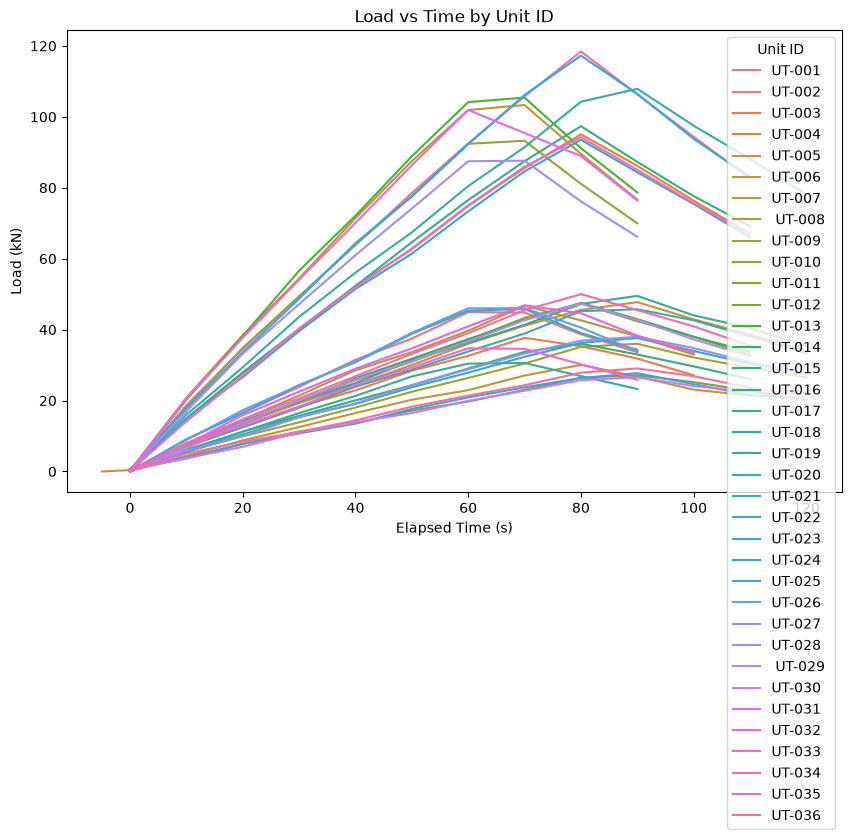

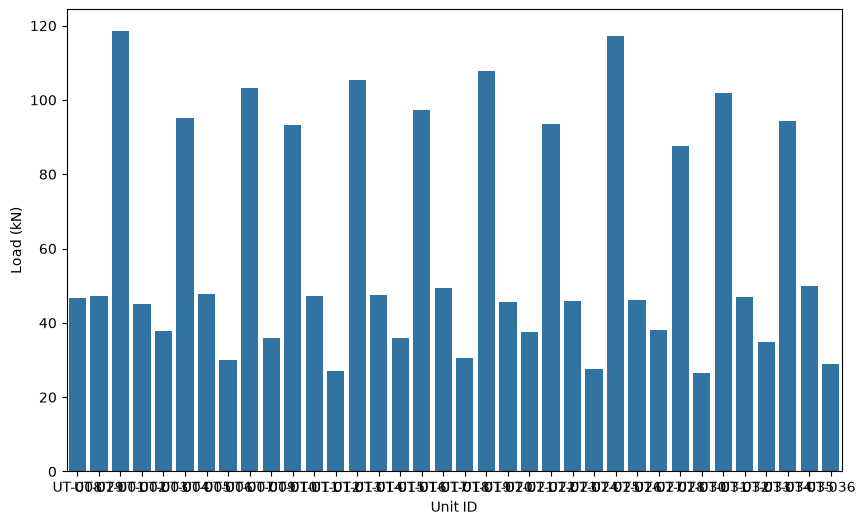

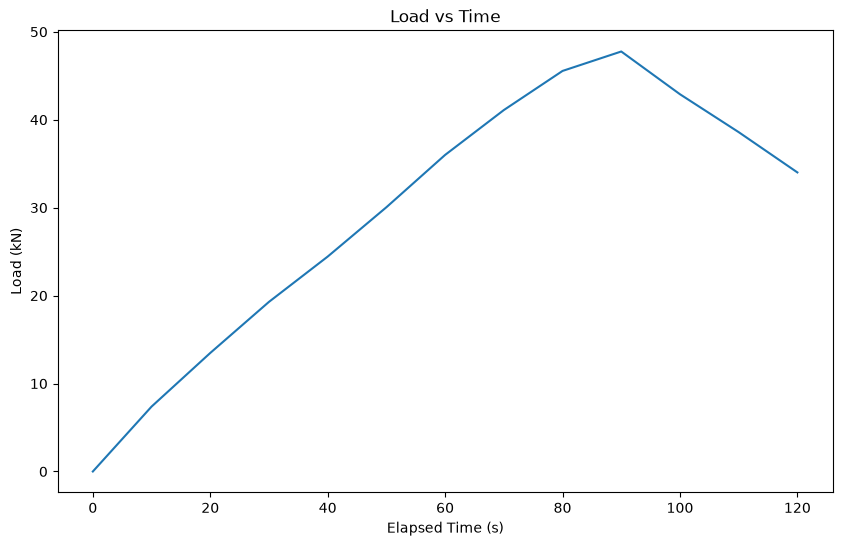

In [19]:
# another class for plotting anything

class Plotter(TensileData):
    def __init__(self, data):
        super().__init__(data)

    def load_vs_time(self, unit_id=None, ax=None):
        if ax is None:
            _, ax = plt.subplots(figsize=(10, 6))
        if unit_id is not None:
            mask = self.data['Unit ID'] == unit_id
            time_data = self.time_data[mask]
            load_data = self.load_data[mask]
        else:
            time_data = self.time_data
            load_data = self.load_data
        sns.lineplot(x=time_data, y=load_data, ax=ax)
        ax.set_title('Load vs Time')
        ax.set_xlabel('Elapsed Time (s)')
        ax.set_ylabel('Load (kN)')
        return ax
    def load_vs_time_by_id(self, ax=None):
        if ax is None:
            _, ax = plt.subplots(figsize=(10, 6))
        sns.lineplot(x=self.time_data, y=self.load_data, hue=self.data['Unit ID'], ax=ax)
        ax.set_title('Load vs Time by Unit ID')
        ax.set_xlabel('Elapsed Time (s)')
        ax.set_ylabel('Load (kN)')
        return ax
    def max_load_by_id(self, ax=None):
        if ax is None:
            _, ax = plt.subplots(figsize=(10,6))
        max_loads = self.data.groupby('Unit ID')['Load (kN)'].max().reset_index()
        sns.barplot(x='Unit ID', y='Load (kN)', data=max_loads, ax=ax)
Plotter(tensileload).load_vs_time_by_id()
Plotter(tensileload).max_load_by_id()
Plotter(tensileload).load_vs_time('UT-005')